In [ ]:
# Descripción del conjunto de datos:
#Se incluyeron varios cientos de pacientes afroamericanos rurales. El archivo diabetes.csv contiene los datos sin procesar de todos los pacientes, incluidos aquellos a los que les faltan datos.
#El archivo Diabetes_Classification fue limpiado y manipulado. Se excluyó a cualquier paciente sin hemoglobina A1c. Si su hemoglobina A1 c era 6,5 o mayor, se les marcaba como diabéticos = sí [columna = "glyhb"]. Se encontró que sesenta de 390 pacientes eran diabéticos.

In [ ]:
#PREGUNTAS DE ANÁLISIS

#1. ¿Cual es el promedio de edad de las personas con niveles de HbA1c fuera de metas? Después clasifique como alto riesgo a las personas mayores de 65 años con niveles de HbA1c fuera de metas y niveles de colesterol por encima de 200.
#2. ¿Existió más prevalencia de la enfermedad en hombres o mujeres?
#3. ¿De las personas que tenían niveles de glucosa estables, cuántas tenían una HbA1c elevada?

In [9]:
import pandas as pd

diabetes_data = pd.read_csv("diabetes.csv")
diabetes_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 403 entries, 0 to 402
Data columns (total 19 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        403 non-null    int64  
 1   chol      402 non-null    float64
 2   stab.glu  403 non-null    int64  
 3   hdl       402 non-null    float64
 4   ratio     402 non-null    float64
 5   glyhb     390 non-null    float64
 6   location  403 non-null    str    
 7   age       403 non-null    int64  
 8   gender    403 non-null    str    
 9   height    398 non-null    float64
 10  weight    402 non-null    float64
 11  frame     391 non-null    str    
 12  bp.1s     398 non-null    float64
 13  bp.1d     398 non-null    float64
 14  bp.2s     141 non-null    float64
 15  bp.2d     141 non-null    float64
 16  waist     401 non-null    float64
 17  hip       401 non-null    float64
 18  time.ppn  400 non-null    float64
dtypes: float64(13), int64(3), str(3)
memory usage: 59.9 KB


In [3]:
diabetes_data [(diabetes_data["glyhb"] > 7) & (diabetes_data["age"] > 65) & (diabetes_data["chol"] > 200)]["age"]

54     70
60     74
67     71
69     91
75     76
108    79
155    75
166    67
180    66
248    73
305    66
312    72
364    84
368    80
Name: age, dtype: int64

In [23]:
#Pregunta 1. ¿Cual es el promedio de edad de las personas con niveles de hemoglobina A1c fuera de metas? Después clasifique como alto riesgo a las personas mayores de 65 años con niveles de HbA1c fuera de metas y niveles de colesterol por encima de 200.
#Contexto: Una diabetes mal controlada o por fuera de metas se determina usualmente con una HbA1c mayor a 7. Por lo tanto, para responder esta pregunta, se filtrará el DF para obtener solo las filas donde 'glyhb' sea mayor a 7, y luego se calculará el promedio de la columna 'age' para esas filas. Posteriormente, se clasificará como alto riesgo a las personas mayores de 65 años con niveles de HbA1c fuera de metas y niveles de colesterol por encima de 200, contando cuántas personas cumplen con esos criterios.

df = pd.read_csv("diabetes.csv")
diabetes_data = diabetes_data.dropna(subset=["glyhb"])

promedio_edad_Hba1c_alta = diabetes_data[diabetes_data['glyhb'] > 7]['age'].mean()
print(f"El promedio de edad de las personas con niveles de HbA1c fuera de metas es: {promedio_edad_Hba1c_alta:.1f} años")

print(f"El número de personas con alto riesgo cardiovascular es: {diabetes_data[(diabetes_data['glyhb'] > 7) & (diabetes_data['age'] > 65) & (diabetes_data['chol'] > 200)]['age'].count()}")

# Verificar conteos
print(diabetes_data["gender"].value_counts())
print(diabetes_data[diabetes_data["glyhb"] >= 6.5]["gender"].value_counts())


El promedio de edad de las personas con niveles de HbA1c fuera de metas es: 58.4 años
El número de personas con alto riesgo cardiovascular es: 14
gender
female    228
male      162
Name: count, dtype: int64
gender
female    36
male      29
Name: count, dtype: int64


In [21]:
# Verificación de calidad de datos
print(f"Total de pacientes: {len(diabetes_data)}")
print(f"Valores nulos por columna:\n{diabetes_data.isna().sum()[diabetes_data.isna().sum() > 0]}")

Total de pacientes: 390
Valores nulos por columna:
chol          1
hdl           1
ratio         1
height        5
weight        1
frame        11
bp.1s         5
bp.1d         5
bp.2s       252
bp.2d       252
waist         2
hip           2
time.ppn      3
dtype: int64


high_risk
No     389
Yes     14
Name: count, dtype: int64


C:\Users\alejo\AppData\Local\Temp\ipykernel_11172\2874291808.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend(title="High Risk")


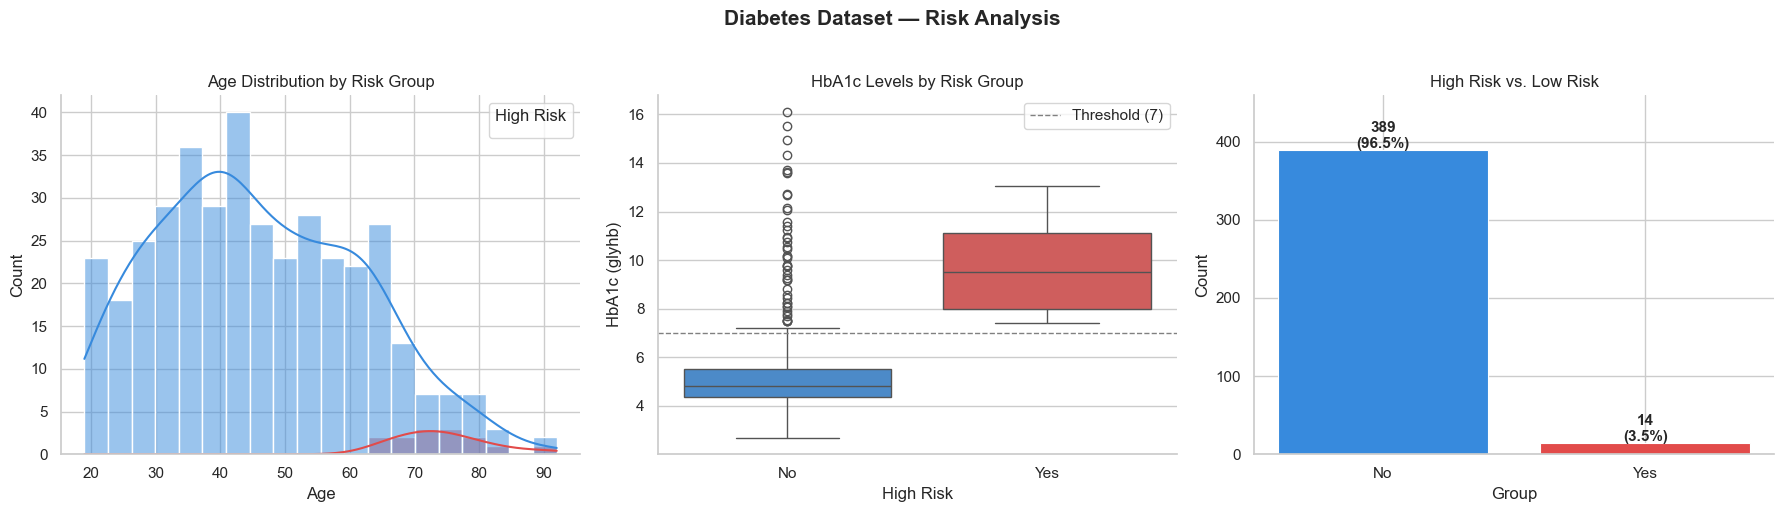

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("diabetes.csv")
diabetes_data = diabetes_data.dropna(subset=["glyhb"])

# Constantes clínicas
HBA1C_THRESHOLD = 7
AGE_THRESHOLD = 65
CHOL_THRESHOLD = 200

# Clasificación de riesgo
df["high_risk"] = (
    (df["glyhb"] > HBA1C_THRESHOLD) &
    (df["age"] > AGE_THRESHOLD) &
    (df["chol"] > CHOL_THRESHOLD)
).map({True: "Yes", False: "No"})

PALETTE = {"Yes": "#E24B4A", "No": "#378ADD"}

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Diabetes Dataset — Risk Analysis", fontsize=15, fontweight="bold", y=1.02)

# Celda 2 — verificar qué valores tiene high_risk ahora
print(df["high_risk"].value_counts())

# Gráfica 1 — Histograma de edades
sns.histplot(
    data=df, x="age", hue="high_risk",
    hue_order=["No", "Yes"], bins=20, kde=True,
    ax=axes[0], palette=PALETTE
)
axes[0].set_title("Age Distribution by Risk Group")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Count")
axes[0].legend(title="High Risk")

# Gráfica 2 — Boxplot de HbA1c
sns.boxplot(
    data=df, x="high_risk", y="glyhb",
    order=["No", "Yes"], hue="high_risk",
    hue_order=["No", "Yes"], palette=PALETTE,
    ax=axes[1], legend=False
)
axes[1].axhline(y=HBA1C_THRESHOLD, color="gray", linestyle="--", linewidth=1, label=f"Threshold ({HBA1C_THRESHOLD})")
axes[1].set_title("HbA1c Levels by Risk Group")
axes[1].set_xlabel("High Risk")
axes[1].set_ylabel("HbA1c (glyhb)")
axes[1].legend()

# Gráfica 3 — Conteo alto riesgo vs normal
risk_counts = df["high_risk"].value_counts().reindex(["No", "Yes"])
colors = [PALETTE[label] for label in risk_counts.index]
bars = axes[2].bar(risk_counts.index, risk_counts.values, color=colors, edgecolor="white", linewidth=0.8)

for bar, val in zip(bars, risk_counts.values):
    pct = val / len(df)
    axes[2].text(bar.get_x() + bar.get_width() / 2, val + 3, f"{val}\n({pct:.1%})", ha="center", fontsize=11, fontweight="bold")

axes[2].set_title("High Risk vs. Low Risk")
axes[2].set_xlabel("Group")
axes[2].set_ylabel("Count")
axes[2].set_ylim(0, max(risk_counts.values) * 1.18)

for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


In [ ]:

# Pregunta 2. ¿Existió más prevalencia de la enfermedad en hombres o mujeres?
import pandas as pd

diabetes_data = pd.read_csv("diabetes.csv")
diabetes_data = diabetes_data.dropna(subset=["glyhb"])

# Criterio diagnóstico: HbA1c >= 6.5 indica diabetes

# Prevalencia = casos con enfermedad / total del grupo

total_hombres = diabetes_data[diabetes_data["gender"] == "male"].shape[0]
total_mujeres = diabetes_data[diabetes_data["gender"] == "female"].shape[0]

if total_hombres > 0:
    prev_hombres = (
        diabetes_data[(diabetes_data["glyhb"] >= 6.5) & (diabetes_data["gender"] == "male")].shape[0] /
        total_hombres
    )
    print(f"Prevalencia en hombres:  {prev_hombres:.1%}")
else:
    print("No hay hombres en el dataset para calcular prevalencia.")
    prev_hombres = 0  # Or None, depending on your needs

if total_mujeres > 0:
    prev_mujeres = (
        diabetes_data[(diabetes_data["glyhb"] >= 6.5) & (diabetes_data["gender"] == "female")].shape[0] /
        total_mujeres
    )
    print(f"Prevalencia en mujeres:  {prev_mujeres:.1%}")
else:
    print("No hay mujeres en el dataset para calcular prevalencia.")
    prev_mujeres = 0  # Or None

# Comparison logic (adjust if prev is 0)
if prev_hombres > prev_mujeres:
    print("Mayor prevalencia en hombres.")
elif prev_mujeres > prev_hombres:
    print("Mayor prevalencia en mujeres.")
else:
    print("Prevalencia igual en ambos grupos.")



Prevalencia en hombres:  17.9%
Prevalencia en mujeres:  15.8%
Mayor prevalencia en hombres.


390


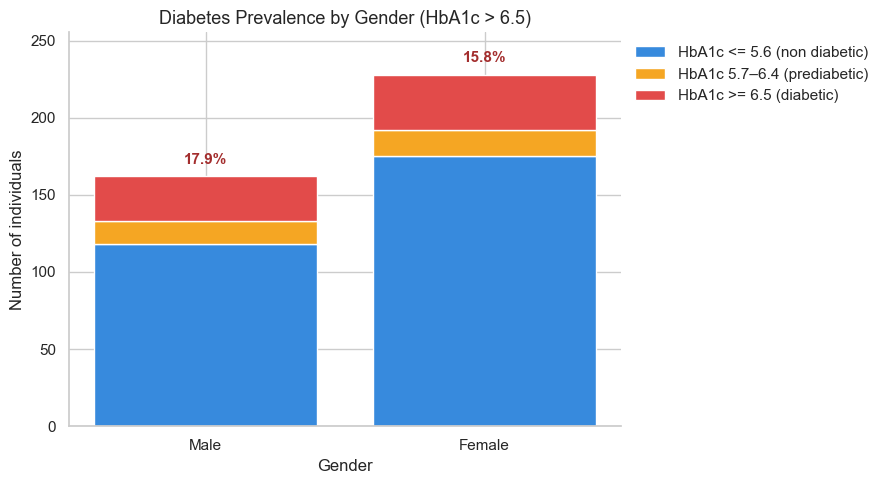

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

diabetes_data = pd.read_csv("diabetes.csv")
diabetes_data = diabetes_data.dropna(subset=["glyhb"])

print(len(diabetes_data)) 

HBA1C_THRESHOLD = 6.5
NONDM_THRESHOLD = 5.6


# --- Calcular conteos por género y estado ---
generos = ["male", "female"]
diabeticos = [
    diabetes_data[(diabetes_data["gender"] == g) & (diabetes_data["glyhb"] >= HBA1C_THRESHOLD)].shape[0]
    for g in generos
]
prediabeticos = [
    diabetes_data[(diabetes_data["gender"] == g) & 
                  (diabetes_data["glyhb"] > NONDM_THRESHOLD) & 
                  (diabetes_data["glyhb"] < HBA1C_THRESHOLD)].shape[0]
    for g in generos
]
sanos = [
    diabetes_data[(diabetes_data["gender"] == g) & 
                  (diabetes_data["glyhb"] <= NONDM_THRESHOLD)].shape[0]
    for g in generos
]
totales = [e + p + s for e, p, s in zip(diabeticos, prediabeticos, sanos)]
prev = [e / t for e, t in zip(diabeticos, totales)]

# --- Gráfica ---
fig, ax = plt.subplots(figsize=(9, 5))

x = np.arange(len(generos))
bars_sanos   = ax.bar(x, sanos,    color="#378ADD", label="HbA1c <= 5.6 (non diabetic)")
bottom_predm = np.array(sanos)
bottom_dm    = np.array(sanos) + np.array(prediabeticos)

bars_prediabeticos = ax.bar(x, prediabeticos, bottom=bottom_predm, color="#F5A623", label="HbA1c 5.7–6.4 (prediabetic)")
bars_diabeticos    = ax.bar(x, diabeticos,    bottom=bottom_dm,    color="#E24B4A", label="HbA1c >= 6.5 (diabetic)")

# Etiqueta de prevalencia encima de cada barra
for i, (total, p) in enumerate(zip(totales, prev)):
    ax.text(i, total + 8, f"{p:.1%}", ha="center", fontsize=11, fontweight="bold", color="#A32D2D")

ax.set_title("Diabetes Prevalence by Gender (HbA1c > 6.5)", fontsize=13)
ax.set_xlabel("Gender")
ax.set_ylabel("Number of individuals")
ax.set_xticks(x)
ax.set_xticklabels(["Male", "Female"])
ax.legend(loc="upper right")
ax.set_ylim(0, max(totales) * 1.12)

ax.legend(
    loc="upper left",
    bbox_to_anchor=(1, 1),
    frameon=False
)
sns.despine()
plt.tight_layout()
plt.show()


In [3]:
#Pregunta 3. ¿De las personas que tenían niveles de glucosa en valores inferiores a prediabetes, cuántas tenían una HbA1c elevada?

import pandas as pd
import numpy as np

diabetes_data = pd.read_csv("diabetes.csv")

GLUCOSE_STABLE_THRESHOLD = 100  # mg/dL 
DIABETES_DIAGNOSTIC_CRITERIA = 6.5  # % 

normal_people = diabetes_data[diabetes_data["stab.glu"] < GLUCOSE_STABLE_THRESHOLD]
discrepancy = normal_people[normal_people["glyhb"] > DIABETES_DIAGNOSTIC_CRITERIA]

total_normal_people = len(normal_people)
total_discrepancy = len(discrepancy)
prevalency = total_discrepancy / total_normal_people

print(f"Personas con glucosa normal (stab.glu < 100):         {total_normal_people}")
print(f"Personas con glucosa normal pero HbA1c elevada (glyhb > 6.5):             {total_discrepancy}")
print(f"Prevalencia:                                            {prevalency:.1%}")

Personas con glucosa normal (stab.glu < 100):         271
Personas con glucosa normal pero HbA1c elevada (glyhb > 6.5):             6
Prevalencia:                                            2.2%


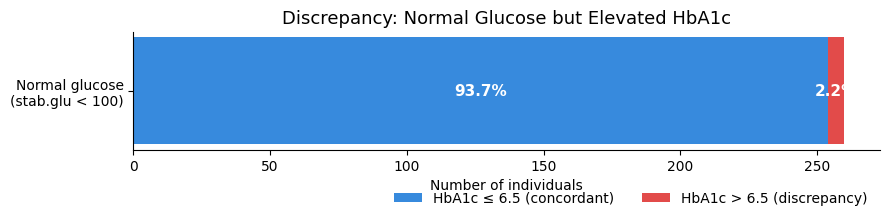

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

diabetes_data = pd.read_csv("diabetes.csv")

# Constantes clínicas
GLUCOSE_THRESHOLD = 100
HBA1C_THRESHOLD = 6.5

# Filtros
normal_people = diabetes_data[diabetes_data["stab.glu"] < GLUCOSE_THRESHOLD]
discrepancy = normal_people[normal_people["glyhb"] > HBA1C_THRESHOLD]
concordant = normal_people[normal_people["glyhb"] <= HBA1C_THRESHOLD]

total_normal = len(normal_people)
total_discrepancy = len(discrepancy)
total_concordant = len(concordant)

pct_discrepancy = total_discrepancy / total_normal
pct_concordant = total_concordant / total_normal

# --- Gráfica ---
fig, ax = plt.subplots(figsize=(9, 2.5))

ax.barh(["Normal glucose\n(stab.glu < 100)"], [total_concordant], color="#378ADD", label=f"HbA1c ≤ 6.5 (concordant)")
ax.barh(["Normal glucose\n(stab.glu < 100)"], [total_discrepancy], left=[total_concordant], color="#E24B4A", label=f"HbA1c > 6.5 (discrepancy)")

# Etiquetas dentro de cada segmento
ax.text(total_concordant / 2, 0, f"{pct_concordant:.1%}", va="center", ha="center", fontsize=11, fontweight="bold", color="white")
ax.text(total_concordant + total_discrepancy / 2, 0, f"{pct_discrepancy:.1%}", va="center", ha="center", fontsize=11, fontweight="bold", color="white")

ax.set_title("Discrepancy: Normal Glucose but Elevated HbA1c", fontsize=13)
ax.set_xlabel("Number of individuals")
ax.legend(loc="upper right", bbox_to_anchor=(1, -0.25), ncol=2, frameon=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
#CONCLUSIONES

#En el dataset publicado en kaggle mencionan 60 pacientes diabeticos, sin embargo, al aplicar el criterio diagnóstico de 
#HbA1c >= 6.5 se encontraron 65 pacientes diabéticos, lo que podría indicar que algunos pacientes no fueron clasificados 
#como diabéticos. 

#Los datos muestran que las personas con un riesgo cardiovascular más elevado se encuentran entre los 70-80 años,
#cabe resaltar, que al colocar el filtro de la edad superior a 65 años se podrían haber excluido personas más jovenes que
#también presentaran un riesgo cardiovascular elevado. 

#Se evidencia como las personas con un riesgo cardiovascular elevado presentan niveles de HbA1c más altos, lo que sugiere 
#un mal control glucémico en este grupo. 

#Las personas con alto riesgo cardiovascular en esta población representan una minoría, lo que podría indicar que la mayoría 
#de los pacientes tienen un riesgo cardiovascular bajo o moderado, aunque esto también podría estar influenciado por los 
#criterios de clasificación utilizados.

#Se encontró una menor prevalencia de la enfermedad en mujeres (15.8%) que en hombres (17.9%), lo que sugiere que los hombres
#en esta población podrían estar más afectados por la diabetes o podrían tener un diagnóstico más frecuente.

#La discrepancia entre glucosa estable y HbA1c >= 6.5 no fue relevante, lo que sugiere que la mayoría de las personas con 
# glucosa estable también tenían niveles de HbA1c dentro de los límites normales, aunque un pequeño porcentaje presentaba 
# una discrepancia que podría indicar un riesgo oculto de diabetes o por el contrario, una diabetes muy bien controlada.